# Statistik Übung

In diesem Notebook geht es um eine kurze Einführung in die nötigen Grundlagen, um Hypothesentests zu verstehen. Als Beispiel betrachten wir das Werfen sechsseitiger Würfel, von denen wir herausfinden wollen, bei welchem Experiment wohl ein fairer Würfel verwendet wurde.

In [1]:
# importiere die notwendigen Pakete
import numpy as np
import matplotlib.pyplot as plt
import scipy

Zunächst betrachten wir vier verschiedene Experimente mit folgendem Outcome, wobei jeweils ein Würfel 30 mal geworfen wurde:

**Exp. 1:**
1: 3, 2: 4, 3: 6, 4: 2, 5: 8, 6: 7

**Exp. 2:**
1: 4, 2: 7, 3: 6, 4: 6, 5: 3, 6: 4

**Exp. 3:**
1: 7, 2: 3, 3: 1, 4: 6, 5: 9, 6: 4

**Exp. 4:**
1: 4, 2: 5, 3: 5, 4: 6, 5: 6, 6: 4

In [2]:
# Anzahl Würfelwürfe
N = 30

# Würfelergebnisse
# Häufigkeiten von 1, 2, 3, 4, 5, 6
exp1_M = np.array([3, 4, 6, 2, 8, 7])
exp2_M = np.array([4, 7, 6, 6, 3, 4])
exp3_M = np.array([7, 3, 1, 6, 9, 4])
exp4_M = np.array([4, 5, 5, 6, 6, 4])

# höchste Anzahl
max_M = np.max(np.concatenate([exp1_M, exp2_M, exp3_M, exp4_M]))

Von einem fairen Würfel erwarten wir, dass jede Zahl gleich wahrscheinlich gewürfelt werden wird. Bei 30 Würfen entspricht das dann also $N/6 = 30/6 = 5$. Aus technischen Gründen speichern wir diesen Erwartungswert auch als Array ab:

In [3]:
# Erwartungswerte
# Häufigkeiten von 1, 2, 3, 4, 5, 6
E = np.array([N/6, N/6, N/6, N/6, N/6, N/6])

Der Fehler auf unseren Messwert entspricht wie bei diskreten Zählexperimenten typischerweise $\Delta M = \sqrt{E}$.

In [4]:
# Fehler auf Messwerte
# (auch als Array)
Delta_M = np.sqrt(E)

# maximaler Fehler
max_Delta_M = np.max(Delta_M)

Wir geben uns aus, wie häufig wir eine *5* gewürfelt haben.

In [18]:
# Printouts zur Kontrolle
erg = 5  # gewünschtes Ergebnis
ix = erg - 1  # Index des gewünschten Ergebnisses

print(f"Wir erwarten bei {N} Würfelwürfen, {E[ix]} +- {Delta_M[ix]:.2f} mal eine {erg} zu würfeln.")
print("Unsere Messergebnisse:")
print(f"    Exp. 1: {exp1_M[ix]}")
print(f"    Exp. 2: {exp2_M[ix]}")
print(f"    Exp. 3: {exp3_M[ix]}")
print(f"    Exp. 4: {exp4_M[ix]}")

Wir erwarten bei 30 Würfelwürfen, 5.0 +- 2.24 mal eine 5 zu würfeln.
Unsere Messergebnisse:
    Exp. 1: 8
    Exp. 2: 3
    Exp. 3: 9
    Exp. 4: 6


Nun wollen wir unsere Experimente als Plot visualisieren.

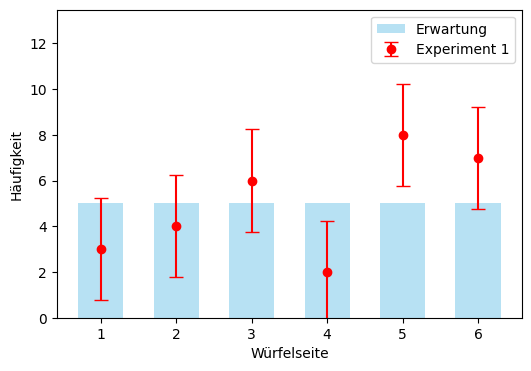

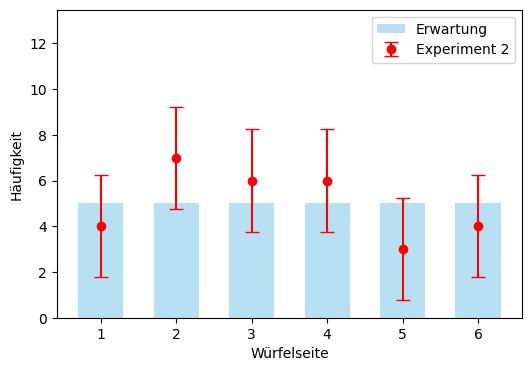

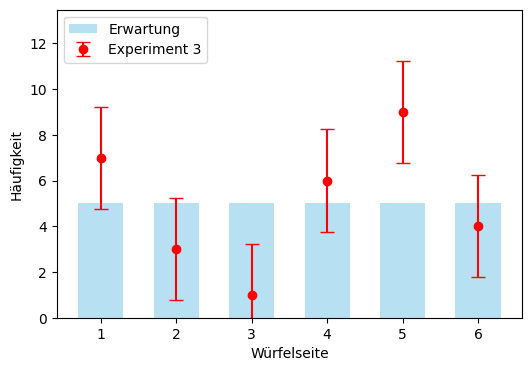

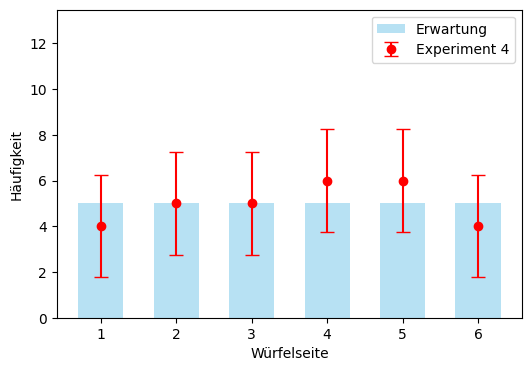

In [19]:
def plot_experiment(exp, label, erwartung, y_max):
    plt.figure(figsize=(6,4))

    # Würfelseiten
    faces = np.arange(1, 7)

    # Histogramm der Erwartungswerte
    plt.bar(faces, erwartung, width=0.6, color="skyblue", alpha=0.6, label="Erwartung")

    # Messwerte als Punkte mit Fehlerbalken
    plt.errorbar(
        faces, exp, yerr=Delta_M,
        fmt="o", color="red", capsize=5, label=label
    )

    # Achsenbeschriftung und Titel
    plt.ylim(0, y_max)
    plt.xlabel("Würfelseite")
    plt.ylabel("Häufigkeit")
    plt.legend()

plot_experiment(exp1_M, "Experiment 1", E, max_M + 2 * max_Delta_M)
plot_experiment(exp2_M, "Experiment 2", E, max_M + 2 * max_Delta_M)
plot_experiment(exp3_M, "Experiment 3", E, max_M + 2 * max_Delta_M)
plot_experiment(exp4_M, "Experiment 4", E, max_M + 2 * max_Delta_M)

**Lässt sich anhand dieser Plots schon erkennen, welches Experiment wohl das Ergebnis eines fairen Würfelwurfs ist? In welchem Experiment passt unser Messergebnis am besten zu unseren Erwartung/Hypothese?

Um zu quantifizieren, wie gut eine Hypothese zu den gemessenen Daten passt, nutzen wir den *chi-squared-Test*. $\chi^2$ ist folgendermaßen definiert:

$\chi^2 = \sum_{i=1}^k \frac{(M_i - E_i)^2}{(\Delta M)^2}$

Die Übereinstimmung zwischen Hypothese und Messung ist besonders gut, wenn das $\chi^2$ klein ist, wenn die Messwerte also wenig von den erwarteten Größen abweichen.

In [7]:
def calculate_chi2(ergebnis, erwartung):
    chi2 = 0
    for i in range(6):
        chi2 += ((ergebnis[i] - erwartung[i]) / Delta_M[i])**2
    return chi2

Für unsere Experimente 1-4 heißt das:

In [8]:
print("Unsere chi2 Werte:")
print(f"    Exp. 1: {calculate_chi2(exp1_M, E):.2f}")
print(f"    Exp. 2: {calculate_chi2(exp2_M, E):.2f}")
print(f"    Exp. 3: {calculate_chi2(exp3_M, E):.2f}")
print(f"    Exp. 4: {calculate_chi2(exp4_M, E):.2f}")

Unsere chi2 Werte:
    Exp. 1: 5.60
    Exp. 2: 2.40
    Exp. 3: 8.40
    Exp. 4: 0.80


Hier bestätigt sich der Eindruck, dass Exp. 4 wohl am besten zur Hypothese des fairen Würfels passt.

Ganz fertig sind wir allerdings noch nicht. Als letzten Schritt berechnen wir aus dem $\chi^2$-Wert den sogennanten *p-value*. Dieser sagt aus, wie wahrscheinlich es ist, das vorliegende Ergebnis aus einer statistischen Fluktuaktion heraus zu bekommen, unter der Annahme, dass die zu überprüfende Hypothese wahr ist. Welche *p-Werte* man beim Hypothesentest akzeptiert, hängt von der Fachrichtung und Situation ab. Wir sind zufrieden, wenn er $> 5\%$ ist.

In [9]:
def p_value(ergebnis, erwartung):
    nbins = 6 - 1  # 6 mögliche Würfelergebnisse - vorgegebene Anzahl Würfelereignisse
    return 1 - scipy.stats.chi2.cdf(calculate_chi2(ergebnis, erwartung), nbins)

Für unsere Experimente 1-4 heißt das:

In [10]:
print("Unsere p-Werte:")
print(f"    Exp. 1: {p_value(exp1_M, E):.4f}")
print(f"    Exp. 2: {p_value(exp2_M, E):.4f}")
print(f"    Exp. 3: {p_value(exp3_M, E):.4f}")
print(f"    Exp. 4: {p_value(exp4_M, E):.4f}")

Unsere p-Werte:
    Exp. 1: 0.3471
    Exp. 2: 0.7915
    Exp. 3: 0.1355
    Exp. 4: 0.9770


Nun haben wir die Bestätigung, dass Exp. 4 wohl am ehesten das Ergebnis eines fairen Würfels war und der Würfel von Exp. 3 am ehesten gezinkt ist. Mit Sicherheit lässt sich das aber erst sagen, wenn man mehr Daten sammelt und die statistische Unsicherheit dadurch kleiner wird.

Wir wiederholen Exp. 1-4 x-mal und berechnen $\chi^2$ und *p-Werte*.

Unsere chi2 Werte:
    Exp. 5: 22.40
    Exp. 6: 9.60
    Exp. 7: 33.60
    Exp. 8: 3.20
Unsere p-Werte:
    Exp. 5: 0.0004
    Exp. 6: 0.0874
    Exp. 7: 0.0000
    Exp. 8: 0.6692
Plots:


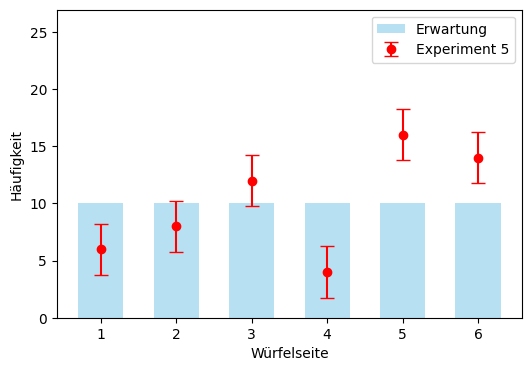

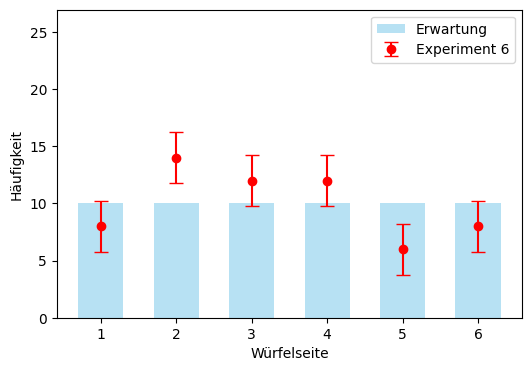

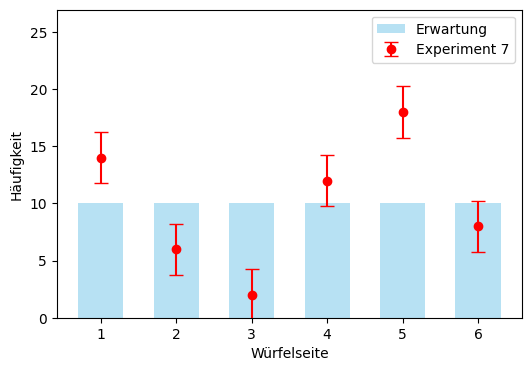

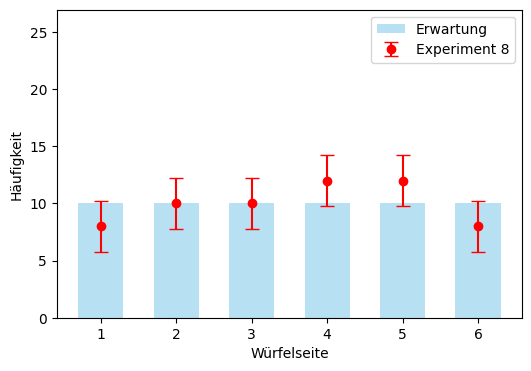

In [11]:
# wir wiederholen das Experiment (30 Würfe) x-mal
# und nehmen an, dass die Ergebnisse gleich verteilt sind wie oben.
multiplikator = 2
neu_erwartung = E * multiplikator

exp5_M = exp1_M * multiplikator
exp6_M = exp2_M * multiplikator
exp7_M = exp3_M * multiplikator
exp8_M = exp4_M * multiplikator

print("Unsere chi2 Werte:")
print(f"    Exp. 5: {calculate_chi2(exp5_M, neu_erwartung):.2f}")
print(f"    Exp. 6: {calculate_chi2(exp6_M, neu_erwartung):.2f}")
print(f"    Exp. 7: {calculate_chi2(exp7_M, neu_erwartung):.2f}")
print(f"    Exp. 8: {calculate_chi2(exp8_M, neu_erwartung):.2f}")

print("Unsere p-Werte:")
print(f"    Exp. 5: {p_value(exp5_M, neu_erwartung):.4f}")
print(f"    Exp. 6: {p_value(exp6_M, neu_erwartung):.4f}")
print(f"    Exp. 7: {p_value(exp7_M, neu_erwartung):.4f}")
print(f"    Exp. 8: {p_value(exp8_M, neu_erwartung):.4f}")

print("Plots:")
plot_experiment(exp5_M, "Experiment 5", neu_erwartung, max_M * multiplikator + 2 * max_Delta_M * multiplikator)
plot_experiment(exp6_M, "Experiment 6", neu_erwartung, max_M * multiplikator + 2 * max_Delta_M * multiplikator)
plot_experiment(exp7_M, "Experiment 7", neu_erwartung, max_M * multiplikator + 2 * max_Delta_M * multiplikator)
plot_experiment(exp8_M, "Experiment 8", neu_erwartung, max_M * multiplikator + 2 * max_Delta_M * multiplikator)

Nach Verdoppeln der Daten haben wir nur bei Exp. 6 und Exp. 8 einen *p-Wert* $> 5\%$.